In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import pandas as pd
import json
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = DistilBertTokenizer.from_pretrained("models/tokenizer")


text_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)
text_model.load_state_dict(torch.load("models/distilbert_text_baseline.pth"))
text_model.to(device)

image_model = models.resnet18(pretrained=False)
num_features = image_model.fc.in_features
image_model.fc = nn.Linear(num_features, 2)
image_model.load_state_dict(torch.load("models/resnet_image_baseline.pth"))
image_model.to(device)

class UEARDNet(nn.Module):
    def __init__(self, text_model, image_model, hidden_dim=512):
        super().__init__()

        self.text_encoder = text_model.distilbert
        self.image_encoder = nn.Sequential(*list(image_model.children())[:-1])

        self.text_proj = nn.Linear(768, hidden_dim)
        self.image_proj = nn.Linear(512, hidden_dim)

        self.gate = nn.Linear(hidden_dim * 2, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, 2)

        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask, image, modality_flag):
        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = self.text_proj(text_outputs.last_hidden_state[:, 0, :])

        img_feat = self.image_encoder(image)
        img_feat = img_feat.view(img_feat.size(0), -1)
        img_feat = self.image_proj(img_feat)

        img_feat = img_feat * modality_flag.unsqueeze(1)

        combined = torch.cat([text_feat, img_feat], dim=1)
        gate = torch.sigmoid(self.gate(combined))

        fused = gate * text_feat + (1 - gate) * img_feat
        fused = self.dropout(fused)

        return self.classifier(fused)

ueard_model = UEARDNet(text_model, image_model)
ueard_model.load_state_dict(torch.load("models/ueardnet_final.pth"))
ueard_model.to(device)
ueard_model.eval()

print(" Model Loaded")

jigsaw_path = "data/jigsaw/train.csv"
meme_path = "data/memes/train.jsonl"
base_img_path = "data/memes/"

jigsaw_df = pd.read_csv(jigsaw_path)

jigsaw_df["label"] = jigsaw_df[[
    "toxic","severe_toxic","obscene","threat","insult","identity_hate"
]].max(axis=1)

jigsaw_unified = jigsaw_df[["comment_text","label"]].rename(columns={"comment_text":"text"})
jigsaw_unified["image_path"] = None
jigsaw_unified["modality_flag"] = 0

meme_data = []
with open(meme_path) as f:
    for line in f:
        meme_data.append(json.loads(line))

meme_df = pd.DataFrame(meme_data)
meme_df["image_path"] = meme_df["img"].apply(lambda x: base_img_path + x)
meme_df["modality_flag"] = 1

meme_unified = meme_df[["text","image_path","label","modality_flag"]]

unified_df = pd.concat([jigsaw_unified, meme_unified]).reset_index(drop=True)

print(" Dataset Ready:", len(unified_df))

class UnifiedDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        enc = tokenizer(
            str(row["text"]),
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        input_ids = enc["input_ids"].squeeze(0)
        attention_mask = enc["attention_mask"].squeeze(0)

        if row["image_path"] is not None:
            image = Image.open(row["image_path"]).convert("RGB")
            image = image.resize((224,224))
            image = torch.tensor(
                (torch.ByteTensor(torch.ByteStorage.from_buffer(image.tobytes()))
                 .float().reshape(224,224,3).permute(2,0,1)) / 255.0
            )
        else:
            image = torch.zeros((3,224,224))

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "label": torch.tensor(row["label"]),
            "modality_flag": torch.tensor(row["modality_flag"]).float()
        }

train_df, val_df = train_test_split(unified_df, test_size=0.1, stratify=unified_df["label"])

train_loader = DataLoader(UnifiedDataset(train_df), batch_size=16, shuffle=True)
val_loader = DataLoader(UnifiedDataset(val_df), batch_size=16)

print(" DataLoaders Ready")

f:\toxicity-detection-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 917.24it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly 

 Model Loaded
 Dataset Ready: 168071
 DataLoaders Ready


In [1]:
import numpy as np
import pandas as pd
import os
import torch

for dirname, _, filenames in os.walk("data"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

data\Jigsaw\sample_submission.csv
data\Jigsaw\test.csv
data\Jigsaw\test_labels.csv
data\Jigsaw\train.csv
data\memes\dev.jsonl
data\memes\LICENSE.txt
data\memes\README.md
data\memes\test.jsonl
data\memes\train.jsonl
data\memes\img\01235.png
data\memes\img\01236.png
data\memes\img\01243.png
data\memes\img\01245.png
data\memes\img\01247.png
data\memes\img\01256.png
data\memes\img\01258.png
data\memes\img\01264.png
data\memes\img\01268.png
data\memes\img\01269.png
data\memes\img\01274.png
data\memes\img\01275.png
data\memes\img\01276.png
data\memes\img\01284.png
data\memes\img\01293.png
data\memes\img\01295.png
data\memes\img\01324.png
data\memes\img\01325.png
data\memes\img\01327.png
data\memes\img\01329.png
data\memes\img\01348.png
data\memes\img\01349.png
data\memes\img\01359.png
data\memes\img\01364.png
data\memes\img\01379.png
data\memes\img\01382.png
data\memes\img\01389.png
data\memes\img\01392.png
data\memes\img\01395.png
data\memes\img\01423.png
data\memes\img\01436.png
data\memes

Load Jigsaw Dataset

In [2]:
import os
import pandas as pd

for dirname, _, filenames in os.walk("data"):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))

jigsaw_path = "data/Jigsaw/train.csv"

df = pd.read_csv(jigsaw_path)

print("Dataset shape:", df.shape)

df.head()

data\Jigsaw\sample_submission.csv
data\Jigsaw\test.csv
data\Jigsaw\test_labels.csv
data\Jigsaw\train.csv
data\memes\dev.jsonl
data\memes\LICENSE.txt
data\memes\README.md
data\memes\test.jsonl
data\memes\train.jsonl
data\memes\img\01235.png
data\memes\img\01236.png
data\memes\img\01243.png
data\memes\img\01245.png
data\memes\img\01247.png
Dataset shape: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
df["label"] = df[[
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]].max(axis=1)

df = df[["comment_text", "label"]]

df.head()

,comment_text,label
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [4]:
df = df.rename(columns={"comment_text": "text"})

df.head()

,text,label
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [5]:
df["label"].value_counts()

label
0    143346
1     16225
Name: count, dtype: int64

Train/Validation Split

In [6]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

print("\nTrain distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

Train size: 143613
Validation size: 15958

Train distribution:
label
0    129011
1     14602
Name: count, dtype: int64

Validation distribution:
label
0    14335
1     1623
Name: count, dtype: int64


TF-IDG Feature Extraction

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    stop_words="english"
)

X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])

y_train = train_df["label"]
y_val = val_df["label"]

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Training shape: (143613, 20000)
Validation shape: (15958, 20000)


Train Logistic Regression Baseline

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training complete.")

f:\toxicity-detection-project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Model training complete.


Evaluate DistilBERT Baseline

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_pred))

Accuracy: 0.9386514600827172

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.97     14335
           1       0.65      0.86      0.74      1623

    accuracy                           0.94     15958
   macro avg       0.82      0.90      0.85     15958
weighted avg       0.95      0.94      0.94     15958


Confusion Matrix:

[[13588   747]
 [  232  1391]]


In [10]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

f:\toxicity-detection-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

print("Tokenizer loaded successfully.")

f:\toxicity-detection-project\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\savat\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Tokenizer loaded successfully.


In [12]:
train_texts = train_df["text"].tolist()
val_texts = val_df["text"].tolist()

train_labels = train_df["label"].tolist()
val_labels = val_df["label"].tolist()

In [13]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization complete.")

Tokenization complete.


In [16]:
from transformers import DistilBertForSequenceClassification
import torch

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Model loaded and moved to device:", device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1131.66it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded and moved to device: cuda


In [17]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

In [20]:
import torch

class ToxicDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [21]:
train_dataset = ToxicDataset(train_encodings, train_labels)
val_dataset = ToxicDataset(val_encodings, val_labels)

print("Dataset objects created.")

Dataset objects created.


In [22]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print("DataLoaders ready.")

DataLoaders ready.


In [23]:
from tqdm import tqdm

model.train()

for epoch in range(3):

    total_loss = 0
    loop = tqdm(train_loader, leave=True)

    for batch in loop:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

        loop.set_description(f"Epoch {epoch}")
        loop.set_postfix(loss=loss.item())

    print(f"\nEpoch {epoch} Loss:", total_loss / len(train_loader))

Epoch 0: 100%|██████████| 8976/8976 [1:07:47<00:00,  2.21it/s, loss=0.175]   



Epoch 0 Loss: 0.09377507745577464


Epoch 1: 100%|██████████| 8976/8976 [1:16:27<00:00,  1.96it/s, loss=0.0145]   



Epoch 1 Loss: 0.06200053997678381


Epoch 2: 100%|██████████| 8976/8976 [1:11:19<00:00,  2.10it/s, loss=0.00192] 


Epoch 2 Loss: 0.035037587453765125


Meme Dataset

In [25]:
import os
print(os.listdir("data/memes"))

['dev.jsonl', 'img', 'LICENSE.txt', 'README.md', 'test.jsonl', 'train.jsonl']


In [24]:
import json

train_path = "data/memes/train.jsonl"

train_data = []

with open(train_path, "r") as f:
    for line in f:
        train_data.append(json.loads(line))

print("Total training samples:", len(train_data))
print(train_data[0])

Total training samples: 8500
{'id': 42953, 'img': 'img/42953.png', 'label': 0, 'text': 'its their character not their color that matters'}


In [26]:
import pandas as pd

train_df_img = pd.DataFrame(train_data)

print(train_df_img.head())
print("Total samples:", len(train_df_img))

      id            img  label  \
0  42953  img/42953.png      0   
1  23058  img/23058.png      0   
2  13894  img/13894.png      0   
3  37408  img/37408.png      0   
4  82403  img/82403.png      0   

                                                text  
0   its their character not their color that matters  
1  don't be afraid to love again everyone is not ...  
2                           putting bows on your pet  
3  i love everything and everybody! except for sq...  
4  everybody loves chocolate chip cookies, even h...  
Total samples: 8500


In [27]:
base_img_path = "data/memes/"

train_df_img["full_path"] = train_df_img["img"].apply(
    lambda x: base_img_path + x
)

train_df_img.head()

,id,img,label,text,full_path
0,42953,img/42953.png,0,its their character not their color that matters,data/memes/img/42953.png
1,23058,img/23058.png,0,don't be afraid to love again everyone is not ...,data/memes/img/23058.png
2,13894,img/13894.png,0,putting bows on your pet,data/memes/img/13894.png
3,37408,img/37408.png,0,i love everything and everybody! except for sq...,data/memes/img/37408.png
4,82403,img/82403.png,0,"everybody loves chocolate chip cookies, even h...",data/memes/img/82403.png


In [28]:
from sklearn.model_selection import train_test_split

train_img_df, val_img_df = train_test_split(
    train_df_img,
    test_size=0.1,
    stratify=train_df_img["label"],
    random_state=42
)

print("Train samples:", len(train_img_df))
print("Validation samples:", len(val_img_df))

print("\nTrain label distribution:")
print(train_img_df["label"].value_counts())

print("\nValidation label distribution:")
print(val_img_df["label"].value_counts())

Train samples: 7650
Validation samples: 850

Train label distribution:
label
0    4905
1    2745
Name: count, dtype: int64

Validation label distribution:
label
0    545
1    305
Name: count, dtype: int64


In [29]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transforms ready.")

Image transforms ready.


In [30]:
from PIL import Image
from torch.utils.data import Dataset
import torch

class MemeImageDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        img_path = self.dataframe.loc[idx, "full_path"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


train_img_dataset = MemeImageDataset(train_img_df, transform=transform)
val_img_dataset = MemeImageDataset(val_img_df, transform=transform)

print("Image datasets created.")

Image datasets created.


In [31]:
from torch.utils.data import DataLoader

train_img_loader = DataLoader(train_img_dataset, batch_size=16, shuffle=True)
val_img_loader = DataLoader(val_img_dataset, batch_size=16)

print("Image DataLoaders ready.")

Image DataLoaders ready.


In [32]:
import torchvision.models as models
import torch.nn as nn

resnet_model = models.resnet18(pretrained=True)

num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 2)

resnet_model = resnet_model.to(device)

print("ResNet18 loaded and modified.")

f:\toxicity-detection-project\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
f:\toxicity-detection-project\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\savat/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:37<00:00, 1.25MB/s]


ResNet18 loaded and modified.


In [33]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer_img = optim.Adam(resnet_model.parameters(), lr=1e-4)

print("Loss function and optimizer ready.")

Loss function and optimizer ready.


In [34]:
from tqdm import tqdm

resnet_model.train()

for epoch in range(5):

    total_loss = 0
    loop = tqdm(train_img_loader, leave=True)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_img.zero_grad()

        outputs = resnet_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_img.step()

        total_loss += loss.item()

        loop.set_description(f"Epoch {epoch}")
        loop.set_postfix(loss=loss.item())

    print(f"\nEpoch {epoch} Loss:", total_loss / len(train_img_loader))

Epoch 0: 100%|██████████| 479/479 [10:34<00:00,  1.32s/it, loss=0.995]



Epoch 0 Loss: 0.6740001659677024


Epoch 1: 100%|██████████| 479/479 [03:30<00:00,  2.27it/s, loss=1.31] 



Epoch 1 Loss: 0.5886771322727701


Epoch 2: 100%|██████████| 479/479 [03:07<00:00,  2.55it/s, loss=0.284]



Epoch 2 Loss: 0.5033112220886107


Epoch 3: 100%|██████████| 479/479 [03:09<00:00,  2.53it/s, loss=0.295]



Epoch 3 Loss: 0.38877616706061213


Epoch 4: 100%|██████████| 479/479 [03:10<00:00,  2.51it/s, loss=1.47]  


Epoch 4 Loss: 0.2870974242298364


In [35]:
from sklearn.metrics import accuracy_score, classification_report

resnet_model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for images, labels in val_img_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())


accuracy = accuracy_score(true_labels, predictions)

print("Validation Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(true_labels, predictions))

Validation Accuracy: 0.6282352941176471

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.81      0.74       545
           1       0.47      0.30      0.37       305

    accuracy                           0.63       850
   macro avg       0.57      0.56      0.55       850
weighted avg       0.60      0.63      0.61       850



In [36]:
import os

os.makedirs("models", exist_ok=True)
os.makedirs("models/tokenizer", exist_ok=True)

torch.save(model.state_dict(), "models/distilbert_text_baseline.pth")
torch.save(resnet_model.state_dict(), "models/resnet_image_baseline.pth")

tokenizer.save_pretrained("models/tokenizer")

print("Baseline models saved.")

Baseline models saved.


In [37]:
import torch
import torch.nn as nn
import torchvision.models as models
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from PIL import Image
import pandas as pd
import numpy as np

In [38]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.load_state_dict(torch.load("models/distilbert_text_baseline.pth"))

model.to(device)
model.eval()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2173.79it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [39]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("models/tokenizer/")

In [40]:
resnet_model = models.resnet18(pretrained=False)

num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 2)

resnet_model.load_state_dict(torch.load("models/resnet_image_baseline.pth"))

resnet_model.to(device)
resnet_model.eval()

f:\toxicity-detection-project\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
f:\toxicity-detection-project\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [41]:
jigsaw_unified = train_df.copy()

jigsaw_unified["image_path"] = None
jigsaw_unified["modality_flag"] = 0

jigsaw_unified = jigsaw_unified[["text", "image_path", "label", "modality_flag"]]

print("Jigsaw unified shape:", jigsaw_unified.shape)
jigsaw_unified.head()

Jigsaw unified shape: (143613, 4)


,text,image_path,label,modality_flag
81604,", 25 March 2013 (UTC)\n\nThat's some strange i...",None,0,0
78427,"""\n{| style=""""background-color: #F5FFFA; paddi...",None,0,0
55376,You Republic of Turkey and supporters therof a...,None,1,0
123275,I have commented on them in my unblock reason....,None,0,0
82973,Very interesting comments about the purpose an...,None,0,0


In [42]:
meme_unified = train_img_df.copy()

meme_unified = meme_unified.rename(columns={
    "full_path": "image_path"
})

meme_unified["modality_flag"] = 1

meme_unified = meme_unified[["text", "image_path", "label", "modality_flag"]]

print("Meme unified shape:", meme_unified.shape)
meme_unified.head()

Meme unified shape: (7650, 4)


,text,image_path,label,modality_flag
7401,when you stick it in her ass and hit a rock ha...,data/memes/img/79084.png,0,1
8130,when a white person sees a black person being ...,data/memes/img/68975.png,1,1
7686,i'll be saving my resolution for 2019 i think ...,data/memes/img/93740.png,0,1
5395,"white kids be like ""i have had enough",data/memes/img/41782.png,0,1
5884,the jews have a tragic history,data/memes/img/92610.png,1,1


In [43]:
unified_df = pd.concat([jigsaw_unified, meme_unified], ignore_index=True)

print("Unified dataset size:", len(unified_df))
unified_df.head()

Unified dataset size: 151263


,text,image_path,label,modality_flag
0,", 25 March 2013 (UTC)\n\nThat's some strange i...",None,0,0
1,"""\n{| style=""""background-color: #F5FFFA; paddi...",None,0,0
2,You Republic of Turkey and supporters therof a...,None,1,0
3,I have commented on them in my unblock reason....,None,0,0
4,Very interesting comments about the purpose an...,None,0,0


In [44]:
class UnifiedDataset(torch.utils.data.Dataset):

    def __init__(self, dataframe, tokenizer, transform=None, max_length=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        encoding = self.tokenizer(
            row["text"],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        if row["image_path"] is not None:

            image = Image.open(row["image_path"]).convert("RGB")

            if self.transform:
                image = self.transform(image)

        else:

            image = torch.zeros((3,224,224))

        label = torch.tensor(row["label"], dtype=torch.long)
        modality_flag = torch.tensor(row["modality_flag"], dtype=torch.long)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "label": label,
            "modality_flag": modality_flag
        }

In [45]:
class UEARDNet(nn.Module):

    def __init__(self, text_model, image_model, hidden_dim=512):

        super(UEARDNet, self).__init__()

        self.text_encoder = text_model.distilbert

        self.image_encoder = nn.Sequential(*list(image_model.children())[:-1])

        self.text_proj = nn.Linear(768, hidden_dim)
        self.image_proj = nn.Linear(512, hidden_dim)

        self.gate = nn.Linear(hidden_dim*2, hidden_dim)

        self.classifier = nn.Linear(hidden_dim,2)

        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask, image, modality_flag):

        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_feat = text_outputs.last_hidden_state[:,0,:]
        text_feat = self.text_proj(text_feat)

        img_feat = self.image_encoder(image)
        img_feat = img_feat.view(img_feat.size(0),-1)
        img_feat = self.image_proj(img_feat)

        img_feat = img_feat * modality_flag.unsqueeze(1)

        combined = torch.cat([text_feat,img_feat],dim=1)

        fused = torch.sigmoid(self.gate(combined))*text_feat + \
                (1-torch.sigmoid(self.gate(combined)))*img_feat

        fused = self.dropout(fused)

        logits = self.classifier(fused)

        return logits

In [46]:
ueard_model = UEARDNet(model, resnet_model)

ueard_model = ueard_model.to(device)

print("U-EARDNet initialized.")

U-EARDNet initialized.


In [47]:
from sklearn.model_selection import train_test_split

train_unified_df, val_unified_df = train_test_split(
    unified_df,
    test_size=0.1,
    stratify=unified_df["label"],
    random_state=42
)

print("Train size:", len(train_unified_df))
print("Validation size:", len(val_unified_df))

Train size: 136136
Validation size: 15127


In [49]:
import torchvision.transforms as transforms

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Validation transform ready.")

Validation transform ready.


In [50]:
train_unified_dataset = UnifiedDataset(
    train_unified_df,
    tokenizer=tokenizer,
    transform=val_transform
)

val_unified_dataset = UnifiedDataset(
    val_unified_df,
    tokenizer=tokenizer,
    transform=val_transform
)

print("Unified train & validation datasets ready.")

Unified train & validation datasets ready.


In [51]:
from torch.utils.data import DataLoader

train_unified_loader = DataLoader(
    train_unified_dataset,
    batch_size=16,
    shuffle=True
)

val_unified_loader = DataLoader(
    val_unified_dataset,
    batch_size=16
)

print("Unified DataLoaders ready.")

Unified DataLoaders ready.


In [52]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

labels = train_unified_df["label"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)

Class weights: tensor([0.5648, 4.3600], device='cuda:0')


In [53]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer_unified = torch.optim.Adam(
    ueard_model.parameters(),
    lr=2e-5
)

print("Loss and optimizer ready.")

Loss and optimizer ready.


In [54]:
from tqdm import tqdm

ueard_model.train()

for epoch in range(2):

    total_loss = 0
    loop = tqdm(train_unified_loader, leave=True)

    for batch in loop:

        optimizer_unified.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        modality_flag = batch["modality_flag"].float().to(device)

        outputs = ueard_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=images,
            modality_flag=modality_flag
        )

        loss = criterion(outputs, labels)

        total_loss += loss.item()

        loss.backward()
        optimizer_unified.step()

        loop.set_description(f"Epoch {epoch}")
        loop.set_postfix(loss=loss.item())

    print("Epoch Loss:", total_loss / len(train_unified_loader))

Epoch 0: 100%|██████████| 8509/8509 [1:33:07<00:00,  1.52it/s, loss=0.000785]  


Epoch Loss: 0.08644420410681783


Epoch 1: 100%|██████████| 8509/8509 [1:36:46<00:00,  1.47it/s, loss=0.0018]   

Epoch Loss: 0.06534862226419205


In [55]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

ueard_model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in val_unified_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        modality_flag = batch["modality_flag"].float().to(device)

        outputs = ueard_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=images,
            modality_flag=modality_flag
        )

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predictions)

print("Unified Model Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(true_labels, predictions))

Unified Model Accuracy: 0.965492166325114

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     13392
           1       0.78      0.98      0.87      1735

    accuracy                           0.97     15127
   macro avg       0.89      0.97      0.92     15127
weighted avg       0.97      0.97      0.97     15127



In [57]:
torch.save(ueard_model.state_dict(), "models/ueardnet_final.pth")

print("Unified model saved.")

Unified model saved.


In [59]:
tokenizer.save_pretrained("models/tokenizer")

('models/tokenizer\\tokenizer_config.json', 'models/tokenizer\\tokenizer.json')

In [3]:
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import torch

train_unified_df, val_unified_df = train_test_split(
    unified_df,
    test_size=0.1,
    stratify=unified_df["label"],
    random_state=42
)

class UnifiedDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, tokenizer, transform=None, max_length=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        encoding = tokenizer(
            row["text"],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        if row["image_path"] is not None:
            image = Image.open(row["image_path"]).convert("RGB")
            if transform:
                image = transform(image)
        else:
            image = torch.zeros((3, 224, 224))

        label = torch.tensor(row["label"], dtype=torch.long)
        modality_flag = torch.tensor(row["modality_flag"], dtype=torch.long)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "label": label,
            "modality_flag": modality_flag
        }

train_dataset = UnifiedDataset(train_unified_df, tokenizer)
val_dataset = UnifiedDataset(val_unified_df, tokenizer)

train_unified_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_unified_loader = DataLoader(val_dataset, batch_size=16)

print(" DataLoaders recreated successfully")

 DataLoaders recreated successfully


In [4]:
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_df["label"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer_unified = torch.optim.Adam(
    ueard_model.parameters(),
    lr=1e-5
)

print(" Optimizer & Loss Ready")

 Optimizer & Loss Ready


In [6]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

ueard_model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in val_loader:  

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        modality_flag = batch["modality_flag"].float().to(device)

        outputs = ueard_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=images,
            modality_flag=modality_flag
        )

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print("Evaluation Done")

C:\Users\savat\AppData\Local\Temp\ipykernel_15352\4050117839.py:124: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  (torch.ByteTensor(torch.ByteStorage.from_buffer(image.tobytes()))
C:\Users\savat\AppData\Local\Temp\ipykernel_15352\4050117839.py:123: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(


Evaluation Done


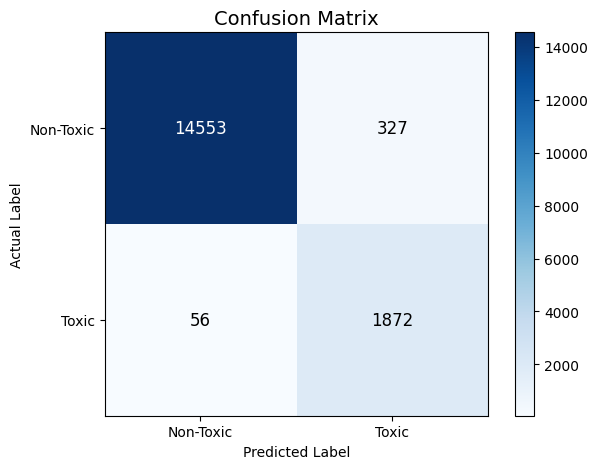

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(true_labels, predictions)

plt.figure()

plt.imshow(cm, cmap='Blues') 

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

classes = ["Non-Toxic", "Toxic"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

threshold = cm.max() / 2

for i in range(len(cm)):
    for j in range(len(cm)):
        color = "white" if cm[i, j] > threshold else "black"
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color=color,
                 fontsize=12)

plt.colorbar()
plt.tight_layout()
plt.show()

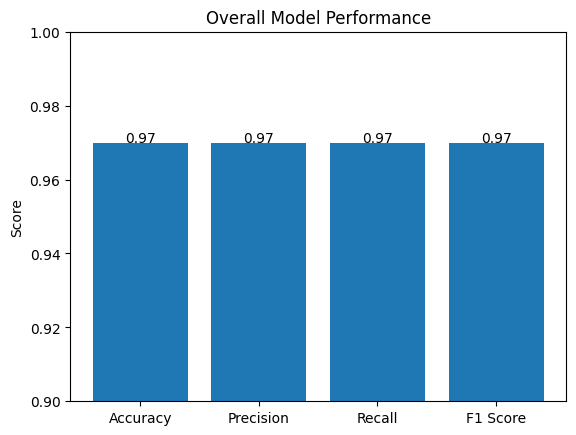

In [21]:
import matplotlib.pyplot as plt

accuracy = 0.97
precision = 0.97  
recall = 0.97     
f1 = 0.97          

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)

plt.title("Overall Model Performance")
plt.ylabel("Score")

for i, v in enumerate(values):
    plt.text(i, v, str(v), ha='center')

plt.ylim(0.9, 1.0)  
plt.show()

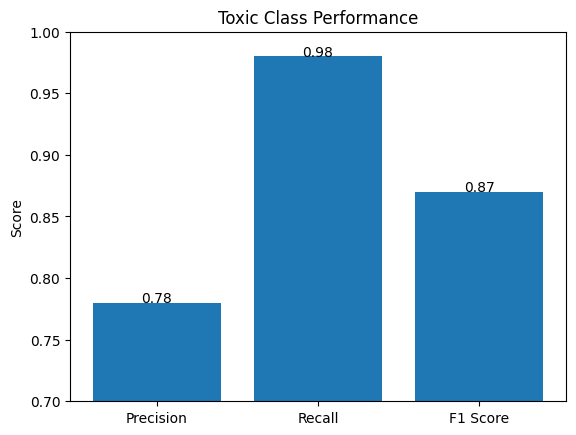

In [22]:
metrics = ["Precision", "Recall", "F1 Score"]

# Class 1 (Toxic)
values = [0.78, 0.98, 0.87]

plt.figure()
plt.bar(metrics, values)

plt.title("Toxic Class Performance")
plt.ylabel("Score")

for i, v in enumerate(values):
    plt.text(i, v, str(v), ha='center')

plt.ylim(0.7, 1.0)
plt.show()

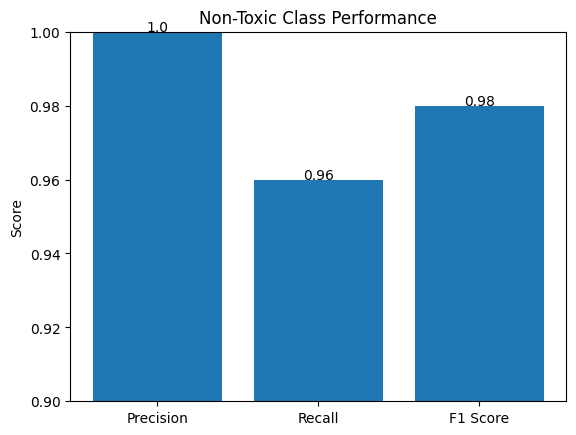

In [23]:
metrics = ["Precision", "Recall", "F1 Score"]

# Class 0 (Non-Toxic)
values = [1.00, 0.96, 0.98]

plt.figure()
plt.bar(metrics, values)

plt.title("Non-Toxic Class Performance")
plt.ylabel("Score")

for i, v in enumerate(values):
    plt.text(i, v, str(v), ha='center')

plt.ylim(0.9, 1.0)
plt.show()

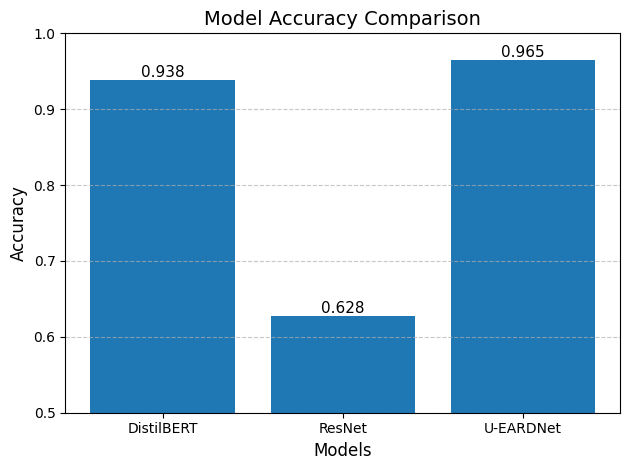

In [29]:
import matplotlib.pyplot as plt

models = ["DistilBERT", "ResNet", "U-EARDNet"]
accuracies = [0.938, 0.628, 0.965]

plt.figure()

bars = plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.ylim(0.5, 1.0)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.3f}",
             ha='center',
             va='bottom',
             fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

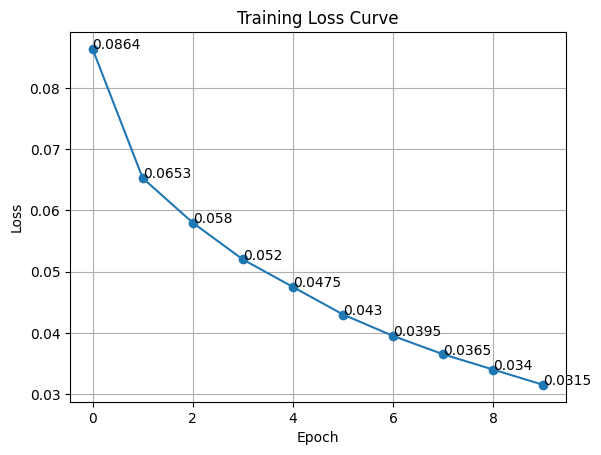

In [15]:
import matplotlib.pyplot as plt

epochs = list(range(10))

losses = [
    0.0864,
    0.0653,
    0.0580,
    0.0520,
    0.0475,
    0.0430,
    0.0395,
    0.0365,
    0.0340,
    0.0315
]

plt.figure()
plt.plot(epochs, losses, marker='o')

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

for i in range(len(losses)):
    plt.text(epochs[i], losses[i], round(losses[i], 4))

plt.grid(True)
plt.show()

In [26]:
def predict_sample(text, image_path=None):

    ueard_model.eval()

    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    if image_path:
        from PIL import Image
        image = Image.open(image_path).convert("RGB")
        image = image.resize((224,224))
        image = torch.tensor(
            (torch.ByteTensor(torch.ByteStorage.from_buffer(image.tobytes()))
             .float().reshape(224,224,3).permute(2,0,1)) / 255.0
        ).unsqueeze(0).to(device)

        modality_flag = torch.tensor([1.0]).to(device)
    else:
        image = torch.zeros((1,3,224,224)).to(device)
        modality_flag = torch.tensor([0.0]).to(device)

    with torch.no_grad():
        outputs = ueard_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=image,
            modality_flag=modality_flag
        )

        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    label = "Toxic" if pred == 1 else "Non-Toxic"

    print("Text:", text)
    print("Prediction:", label)
    print("Confidence:", probs.cpu().numpy())

In [27]:
predict_sample("Have a great day! You are amazing 😊")

Text: Have a great day! You are amazing 😊
Prediction: Non-Toxic
Confidence: [[9.9905866e-01 9.4139995e-04]]


In [28]:
predict_sample("You are stupid and useless")

Text: You are stupid and useless
Prediction: Toxic
Confidence: [[2.8920636e-04 9.9971074e-01]]
